<a id="from-two-point-clouds-to-a-differentiable-loss"></a>

# From two point clouds to a differentiable loss

[Tutorials and examples](../README.md) · Next: [Choose parameters and check the result](../choosing_parameters/guide.ipynb)

Suppose a model produces a set of points and you have a target set. The points are unordered: row 12 in one set
need not correspond to row 12 in the other. Optimal transport compares the distributions represented by the
sets, using both the locations of their points and the mass assigned to each point.

This tutorial follows one problem from beginning to end. We translate a point cloud, measure the discrepancy,
inspect how mass moves, and learn the translation with PyTorch. The known translation gives us a way to check
our interpretation of the output. At the end, you will know which output to use as a training loss, which output
describes transport, and why those outputs need different accuracy checks.

Source: [first_steps.md](first_steps.md) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/getting_started/first_steps.md').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/getting_started/first_steps.md')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

<a id="run-the-lesson"></a>

## Run the lesson

You need an NVIDIA CUDA GPU and a clone of this repository for the example files. Install the released package
and plotting dependencies:

```bash
pip install --upgrade "flash-sinkhorn[examples]"
```

Run the Python blocks below in order, in one Python session or notebook started from the repository root.
They use 16,384 points per cloud. Only small subsets are drawn; the loss uses every point. The code saves the
two figures displayed in this page beside the other getting-started images.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

if not torch.cuda.is_available():
    raise RuntimeError("This tutorial requires an NVIDIA CUDA GPU.")

torch.manual_seed(0)
device = "cuda"
n = 16_384
x0 = 0.25 * torch.randn(n, 2, device=device)
translation = torch.tensor([0.6, 0.3], device=device)
y = x0 + translation
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((n,), 1.0 / n, device=device)
image_dir = Path("examples/getting_started/images")
image_dir.mkdir(parents=True, exist_ok=True)

Each row of `x0` or `y` is a location. Each entry of `a` or `b` is its mass. The weights sum to one on each side,
so these are probability distributions. A point represents a small share of the distribution, not an object
that must be assigned to exactly one target point. The explicit weights make this visible; `loss(x0, y)` would
use uniform weights automatically.
The translated-copy construction gives us a known answer; the solver receives coordinates and weights, without
any pairing labels.

<a id="cost-plan-potentials-loss-four-different-objects"></a>

## Cost, plan, potentials, loss: four different objects

For this lesson the cost of sending mass from point `x[i]` to point `y[j]` is

$$
C_{ij}=\tfrac12\lVert x_i-y_j\rVert^2.
$$

The factor one half is selected with `half_cost=True`. Keep it explicit: flash-sinkhorn's default is the full
squared distance, whereas GeomLoss's `p=2` convention uses the half cost.

The **transport plan** `P[i, j]` says how much mass is sent along that pair. In balanced transport its row sums
are `a` and its column sums are `b`. For example, the following two plans both move two equal source masses to
two equal target masses:

$$
P_{\rm concentrated}=\begin{pmatrix}1/2&0\\0&1/2\end{pmatrix},\qquad
P_{\rm spread}=\begin{pmatrix}1/4&1/4\\1/4&1/4\end{pmatrix}.
$$

The first keeps the assignments concentrated. The second splits every source mass between both targets.
Entropic regularization trades transport cost against how concentrated the plan is. Its strength is
`eps = blur**2`. A larger blur favors broader coupling; it does not add random noise to your input points.

| Object | What it answers | Shape in this example |
|---|---|---|
| Pair cost `C` | How expensive is one possible move? | Conceptually `(n, n)` |
| Plan `P` | How much mass moves along each pair? | Conceptually `(n, n)` |
| Potentials `f, g` | Which per-point dual values define the regularized plan? | `(n,)`, `(n,)` |
| Loss | How different are the two distributions under the chosen objective? | Scalar |

Flash-sinkhorn evaluates pair interactions in tiles. It does not construct the full `C` or `P` matrices in
these solves. Requesting potentials returns the two vectors, not an allocation of the transport matrix.

<a id="choose-the-objective-before-interpreting-the-number"></a>

## Choose the objective before interpreting the number

The raw entropic OT cost includes a smoothing bias: even transporting a cloud to itself can have a nonzero
cost. The Sinkhorn divergence removes the two self-interaction terms:

$$
S_\varepsilon(x,y)=\operatorname{OT}_\varepsilon(x,y)
-\tfrac12\operatorname{OT}_\varepsilon(x,x)
-\tfrac12\operatorname{OT}_\varepsilon(y,y).
$$

Use `debias=True` for this divergence, or `debias=False` for the raw entropic cost. We evaluate both on the
same data. This lesson uses FP32 dot products so the coordinate-rounding choice does not obscure the formulas.
The [next tutorial](../choosing_parameters/guide.ipynb#precision-and-the-coordinates-being-solved) explains the
default TF32 setting.

In [ ]:
blur = 0.2
settings = dict(blur=blur, half_cost=True, scaling=0.9,
                allow_tf32=False, autotune=False)
divergence = SamplesLoss(debias=True, **settings)
raw_ot = SamplesLoss(debias=False, **settings)

print("self raw OT:", raw_ot(a, x0, a, x0).item())
print("self Sinkhorn divergence:", divergence(a, x0, a, x0).item())
print("translated raw OT:", raw_ot(a, x0, b, y).item())
print("translated Sinkhorn divergence:", divergence(a, x0, b, y).item())
expected = 0.5 * translation.square().sum()
print("translation identity, half squared distance:", expected.item())
print("numerical error against that identity:",
      (divergence(a, x0, b, y) - expected).item())

Captured output from the accompanying run; rerun the code for results on your device:

```text
self raw OT: 0.06399285793304443
self Sinkhorn divergence: 0.0
translated raw OT: 0.28899073600769043
translated Sinkhorn divergence: 0.2250000238418579
translation identity, half squared distance: 0.22500000894069672
numerical error against that identity: 1.4901161193847656e-08
```

For identical probability clouds related by a translation `t`, the converged Sinkhorn divergence with this
cost is `|t|**2 / 2` in real arithmetic, for every blur. The printed difference is a numerical diagnostic;
the formula does not promise an error-free finite solve. Try changing `blur` and compare the raw cost with the
divergence. They measure different objectives, so a larger raw cost is not evidence of a worse implementation.

<a id="read-a-gradient-as-a-direction-of-motion"></a>

## Read a gradient as a direction of motion

The coordinate gradient has the same shape as the source cloud. A negative gradient step moves the source to
reduce the chosen loss. For a converged balanced **raw OT** solve with the half cost,

$$
\nabla_{x_i}\operatorname{OT}_\varepsilon=a_i(x_i-T_i),\qquad
T_i=\frac{\sum_jP_{ij}y_j}{\sum_jP_{ij}}.
$$

`T[i]` is the barycentric target: an average under a row of the plan. It need not equal one of the target
points. The negative gradient divided by the point mass is therefore a displacement toward that average.
The divergence also subtracts the source self-interaction gradient; its arrows should not be interpreted as
the raw plan's barycentric targets.

In [ ]:
def coordinate_gradient(objective):
    x = x0.clone().requires_grad_(True)
    value = objective(a, x, b, y)
    (gradient,) = torch.autograd.grad(value, x)
    return gradient.detach()

raw_direction = -coordinate_gradient(raw_ot) / a[:, None]
debiased_direction = -coordinate_gradient(divergence) / a[:, None]
print("raw direction finite:", bool(torch.isfinite(raw_direction).all()))
print("debiased direction finite:", bool(torch.isfinite(debiased_direction).all()))

draw = torch.arange(0, n, n // 80, device=device)[:80]
points = x0[draw].cpu().numpy()
target = y[::16].cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for ax, direction, title in zip(
    axes, (raw_direction, debiased_direction),
    ("Raw OT: transport plus smoothing bias", "Divergence: subtract the self interaction"),
):
    vectors = direction[draw].cpu().numpy()
    ax.scatter(target[:, 0], target[:, 1], s=5, alpha=0.25, color="#d97706", label="target")
    ax.scatter(points[:, 0], points[:, 1], s=10, color="#2563eb", label="source")
    ax.quiver(points[:, 0], points[:, 1], vectors[:, 0], vectors[:, 1],
              angles="xy", scale_units="xy", scale=1, color="#334155", width=0.003)
    ax.set(xlim=(-0.9, 1.5), ylim=(-0.9, 1.2), xlabel="coordinate 1", ylabel="coordinate 2", title=title)
    ax.set_aspect("equal")
axes[0].legend(frameon=False, loc="upper left")
fig.savefig(image_dir / "tutorial_directions.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/tutorial_directions.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

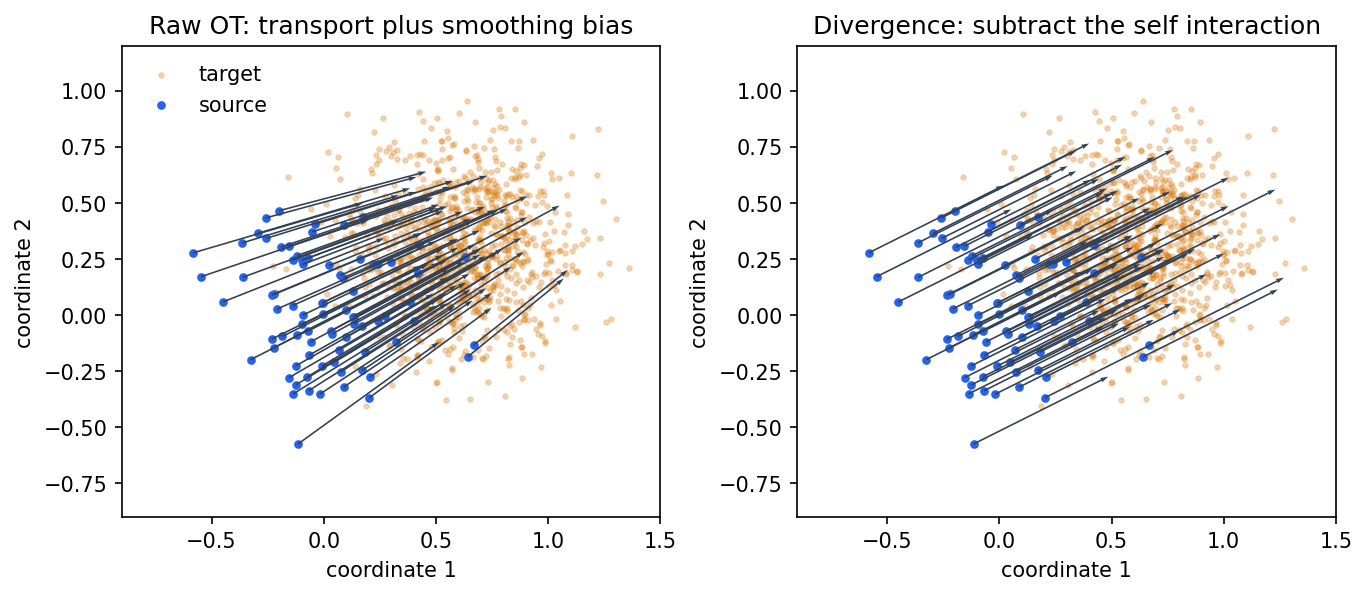

Read the left panel from the source points to the arrow tips. Entropic averaging can pull points toward the
interior of the target distribution. On the right, subtracting the self interaction removes that bias for the
translated-copy example, leaving nearly parallel translation directions. Both panels use the same blur and
the same points. Compare them again after increasing the blur.

Dividing by `a` here defines a particle displacement for visualization or a mass-weighted particle flow.
Ordinary neural-network training uses `loss.backward()` directly; do not insert this division into a model's
parameter gradients.

<a id="put-the-loss-in-an-optimization-loop"></a>

## Put the loss in an optimization loop

To separate the loss from the model, let the model have just two parameters: a shared translation `offset`.
Its output is `x0 + offset`. PyTorch sums the contribution of every point when differentiating with respect
to that shared parameter.

In [ ]:
offset = torch.zeros(2, device=device, requires_grad=True)
optimizer = torch.optim.SGD([offset], lr=0.5)
losses = [divergence(a, x0, b, y).item()]
for _ in range(8):
    optimizer.zero_grad()
    value = divergence(a, x0 + offset, b, y)
    value.backward()
    optimizer.step()
    losses.append(divergence(a, x0 + offset, b, y).item())

print("known translation:", translation.tolist())
print("learned translation:", offset.detach().tolist())
print("loss before and after:", losses[0], losses[-1])

fig, (ax_points, ax_loss) = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
start = x0[::32].cpu().numpy()
fitted = (x0 + offset.detach())[::32].cpu().numpy()
target = y[::32].cpu().numpy()
ax_points.scatter(start[:, 0], start[:, 1], s=7, alpha=0.35, color="#2563eb", label="initial source")
ax_points.scatter(target[:, 0], target[:, 1], s=14, facecolors="none", edgecolors="#d97706", label="target")
ax_points.scatter(fitted[:, 0], fitted[:, 1], s=5, color="#15803d", label="fitted source")
ax_points.set(xlabel="coordinate 1", ylabel="coordinate 2", title="Learn one shared translation")
ax_points.set_aspect("equal")
ax_points.legend(frameon=False)
ax_loss.semilogy(range(len(losses)), losses, "o-", color="#15803d")
ax_loss.set(xlabel="optimization step", ylabel="Sinkhorn divergence", title="Evaluate after each step")
fig.savefig(image_dir / "tutorial_fit.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/tutorial_fit.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

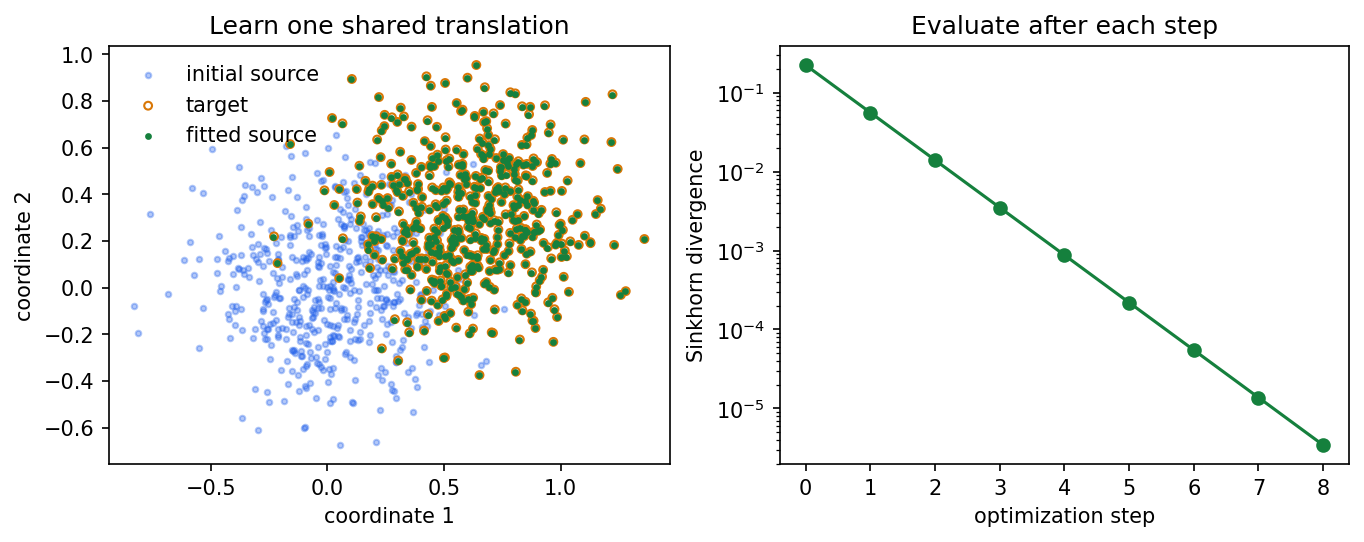

The same run prints:

```text
known translation: [0.6000000238418579, 0.30000001192092896]
learned translation: [0.5976563096046448, 0.2988281548023224]
loss before and after: 0.2250000238418579 3.427267074584961e-06
```

The fitted cloud should approach the target while the objective decreases. We constructed the target by a
translation, so the fitted parameters can also be checked directly. For a learned shape or embedding, you
usually lack this known answer; that is when convergence and task-specific validation become more important.

<a id="inspect-transport-separately-from-the-training-loss"></a>

## Inspect transport separately from the training loss

Request the potentials of the cross problem with `potentials=True`. These are the raw OT potentials even
if `debias=True` is supplied, so we keep `debias=False` explicit. In the convention returned by `SamplesLoss`,

$$
P_{ij}=a_i b_j\exp\bigl((f_i+g_j-C_{ij})/\varepsilon\bigr).
$$

Adding a constant to `f` and subtracting it from `g` leaves `P` unchanged. This is why the absolute levels of
balanced potentials are not a useful agreement test between solvers. Their implied plan is more informative.

The repository's `_transport` helpers apply that plan in tiles. From the repository root, the following block
checks mass conservation without constructing the full matrix. It uses the same weights, half cost, epsilon,
and FP32 coordinates as the solve.

In [ ]:
from examples._transport import barycentric_targets, marginals

potentials = SamplesLoss(blur=blur, half_cost=True, debias=False, potentials=True,
                         scaling=0.95, allow_tf32=False, autotune=False)
f, g = potentials(a, x0, b, y)
row, column = marginals(x0, y, f, g, a, b, eps=blur**2, cost_scale=0.5)
targets = barycentric_targets(x0, y, f, g, a, b, eps=blur**2, cost_scale=0.5)
print("source marginal L1 residual:", (row - a).abs().sum().item())
print("target marginal L1 residual:", (column - b).abs().sum().item())
print("potential shapes:", tuple(f.shape), tuple(g.shape))
print("barycentric target shape:", tuple(targets.shape))

For balanced OT, row and column masses should approach the supplied weights as the solve converges. A plausible
scalar loss alone does not certify that the plan has converged. The [`_transport.py`](../_transport.py) helpers
belong to these repository examples; their precision and coordinate conventions are stated in that file.

Make that distinction observable: solve again at the same target epsilon, this time taking more updates at
that epsilon. The next block changes the iteration schedule, while keeping the mathematical problem and
precision fixed. This second solve starts from its own initialization. Compare the marginal residuals with
the earlier loss check.

In [ ]:
refined_potentials = SamplesLoss(
    half_cost=True, debias=False, potentials=True, allow_tf32=False, autotune=False,
    use_epsilon_scaling=False, eps=blur**2, n_iters=200,
)
f_refined, g_refined = refined_potentials(a, x0, b, y)
row_refined, column_refined = marginals(
    x0, y, f_refined, g_refined, a, b, eps=blur**2, cost_scale=0.5,
)
initial_residual = max((row - a).abs().sum().item(), (column - b).abs().sum().item())
refined_residual = max((row_refined - a).abs().sum().item(), (column_refined - b).abs().sum().item())
print("plan residual before and after refinement:", initial_residual, refined_residual)

Captured output:

```text
plan residual before and after refinement: 0.004248300101608038 7.041599019430578e-07
```

In this example the scalar divergence can already be close to its known answer while the plan still benefits
from further iterations. On new data, choose an acceptance criterion for the quantity you actually use.
Increasing an iteration count is an experiment whose outcome you check, not a guarantee that every problem
will meet your criterion.

<a id="check-your-understanding"></a>

## Check your understanding

- Increase the blur. Which part of the raw-gradient picture changes? Does the translated-copy divergence still
  approach its known answer when the solve is sufficiently accurate?
- Replace `y` by `x0`. Explain why the raw cost and the divergence behave differently.
- Give the model one shared translation parameter, then give every particle its own coordinates. Explain why
  the gradient has a different shape and why the particle-flow example divides by masses.
- Shuffle the target points and their weights together. Explain why their row order should not define the
  mathematical loss.
- Shift the balanced potentials by `f -> f + c` and `g -> g - c`. Does their plan change?

Continue with [Choose parameters and check the result](../choosing_parameters/guide.ipynb), then run the
[blob-to-arc example](plot_sinkhorn_basics.ipynb) and [particle gradient flow](plot_gradient_flow_2d.ipynb). Those
examples keep the same concepts while changing the geometry and increasing the scale.